In [2]:
import pandas as pd

df = pd.read_csv("pcf_dataset.csv")



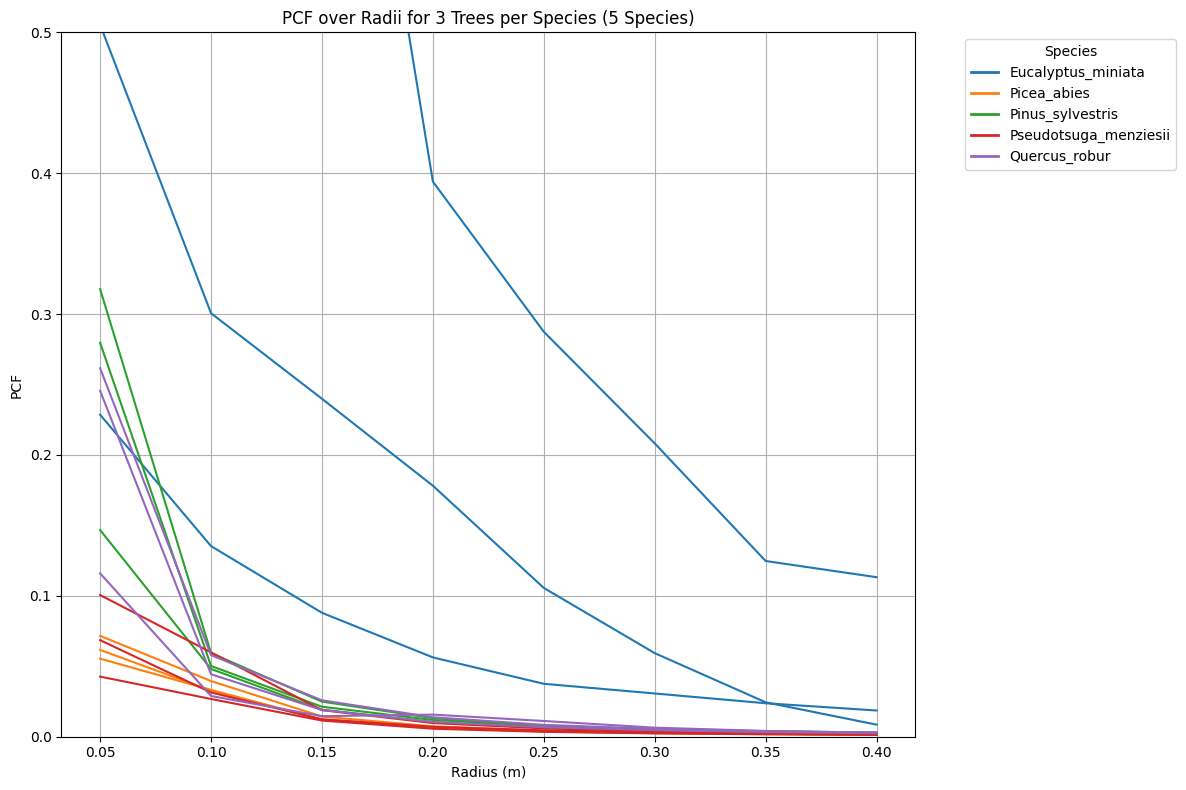

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

# Select 5 species, and for each, select 3 trees
species_list = df['species'].unique()[:5]
sample_trees = df[df['species'].isin(species_list)].groupby('species').head(3)

# Extract radii from column names
radii = [float(col.split('_')[-1]) for col in df.columns if col.startswith('pcf_t_')]
pcf_cols = [col for col in df.columns if col.startswith('pcf_t_')][:8]

# Assign a color to each species
species_colors = dict(zip(species_list, plt.cm.tab10.colors[:len(species_list)]))

plt.figure(figsize=(12, 8))
for idx, row in sample_trees.iterrows():
    color = species_colors[row['species']]
    plt.plot(radii[:8], row[pcf_cols], label=f"{row['species']} (TreeID {row['treeID']})", color=color)

# Create custom legend for species
handles = [plt.Line2D([0], [0], color=species_colors[sp], lw=2, label=sp) for sp in species_list]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title='Species')

plt.ylim((0,0.5))
plt.xlabel('Radius (m)')
plt.ylabel('PCF')
plt.title('PCF over Radii for 3 Trees per Species (5 Species)')
plt.grid(True)
plt.tight_layout()
plt.show()

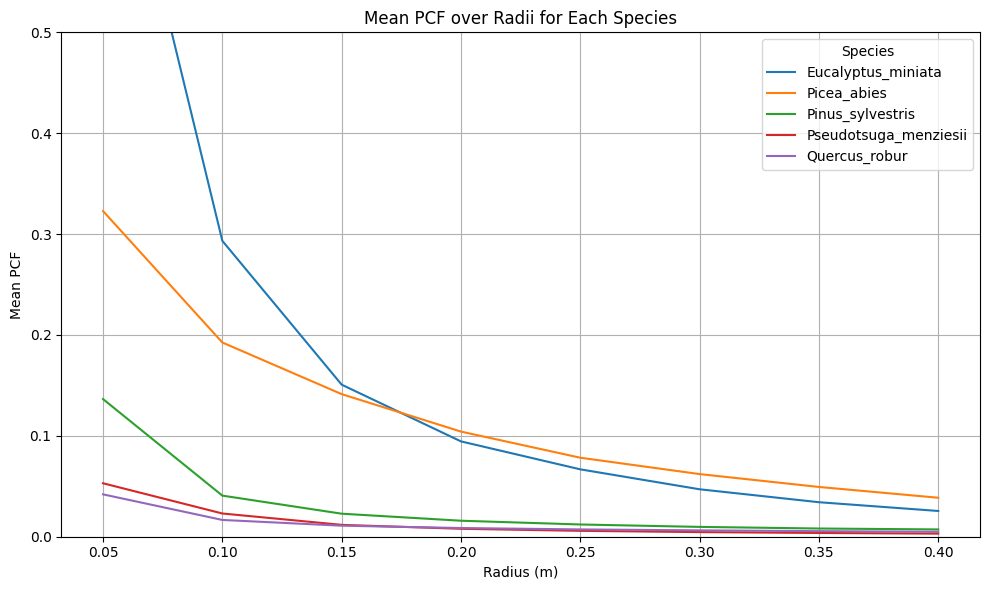

In [4]:
# Plot mean PCF for each species at each radius
mean_pcf_per_species = (
    df.groupby('species')[pcf_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for sp in species_list:
    plt.plot(
        radii[:8],
        mean_pcf_per_species[mean_pcf_per_species['species'] == sp][pcf_cols].values.flatten(),
        label=sp,
        color=species_colors[sp]
    )
plt.xlabel('Radius (m)')
plt.ylabel('Mean PCF')
plt.title('Mean PCF over Radii for Each Species')
plt.legend(title='Species')
plt.ylim((0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'Larix_decidua'

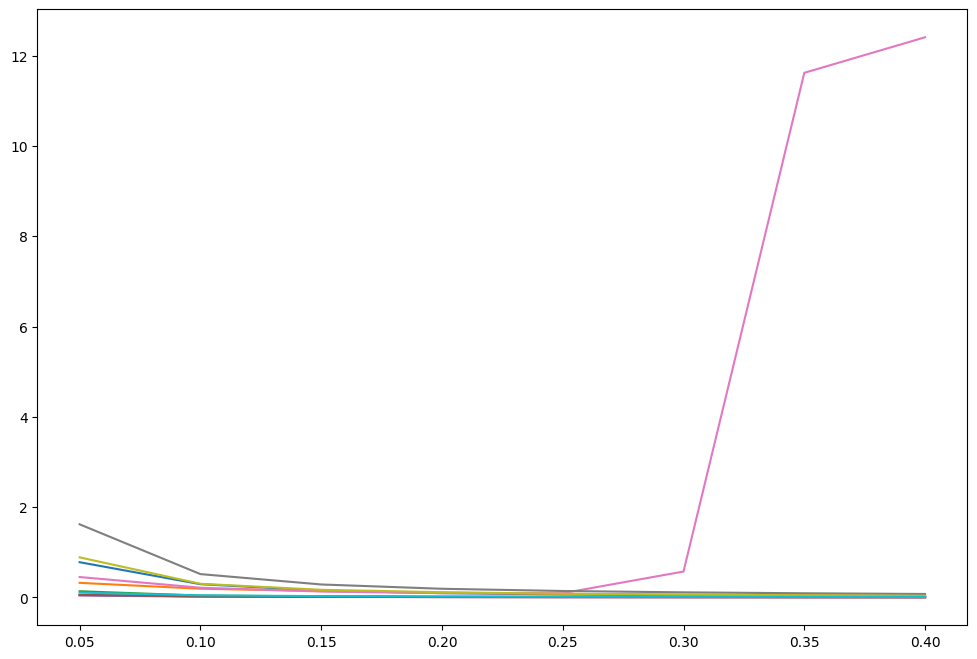

In [6]:
# Plot mean PCF for 10 different species at each radius
species_list_10 = df['species'].unique()[:33]
mean_pcf_per_species_10 = (
    df[df['species'].isin(species_list_10)]
    .groupby('species')[pcf_cols]
    .mean()
    .reset_index()
)
species_colors_10 = dict(zip(species_list_10, plt.cm.tab10.colors[:len(species_list_10)]))

plt.figure(figsize=(12, 8))
for sp in species_list_10:
    plt.plot(
        radii[:8],
        mean_pcf_per_species_10[mean_pcf_per_species_10['species'] == sp][pcf_cols].values.flatten(),
        label=sp,
        color=species_colors_10[sp]
    )
plt.xlabel('Radius (m)')
plt.ylabel('Mean PCF')
plt.title('Mean PCF over Radii for 10 Species')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim((0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\mathe\AppData\Local\Temp\ipykernel_30028\2125793538.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.get_cmap('hsv', n)


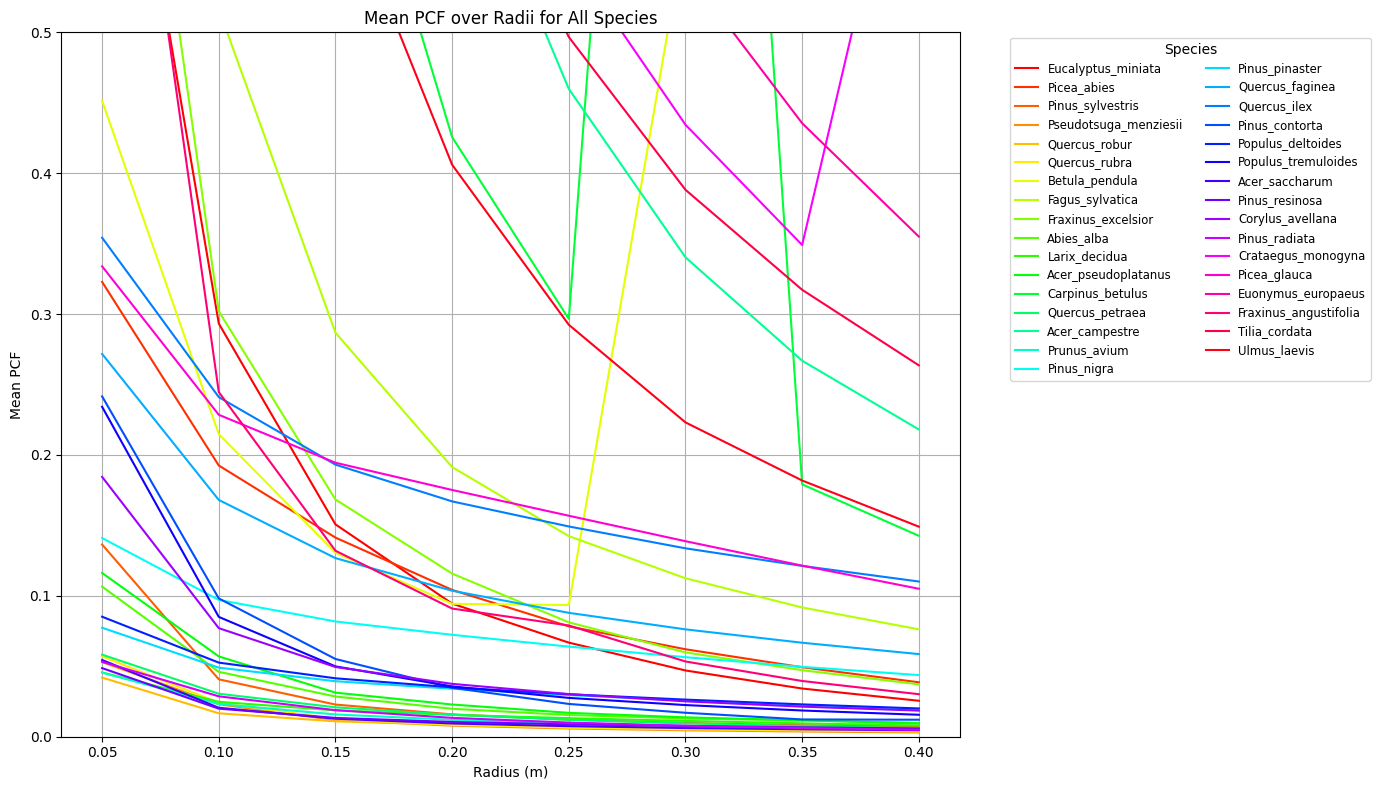

In [7]:
# Plot mean PCF for all species at each radius
all_species = df['species'].unique()
mean_pcf_per_species_all = (
    df.groupby('species')[pcf_cols]
    .mean()
    .reset_index()
)
# Use a colormap that can handle many colors
def get_n_colors(n):
    cmap = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.get_cmap('hsv', n)
    return [cmap(i) for i in range(n)]
species_colors_all = dict(zip(all_species, get_n_colors(len(all_species))))

plt.figure(figsize=(14, 8))
for sp in all_species:
    plt.plot(
        radii[:8],
        mean_pcf_per_species_all[mean_pcf_per_species_all['species'] == sp][pcf_cols].values.flatten(),
        label=sp,
        color=species_colors_all[sp]
    )
plt.xlabel('Radius (m)')
plt.ylabel('Mean PCF')
plt.title('Mean PCF over Radii for All Species')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.ylim((0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

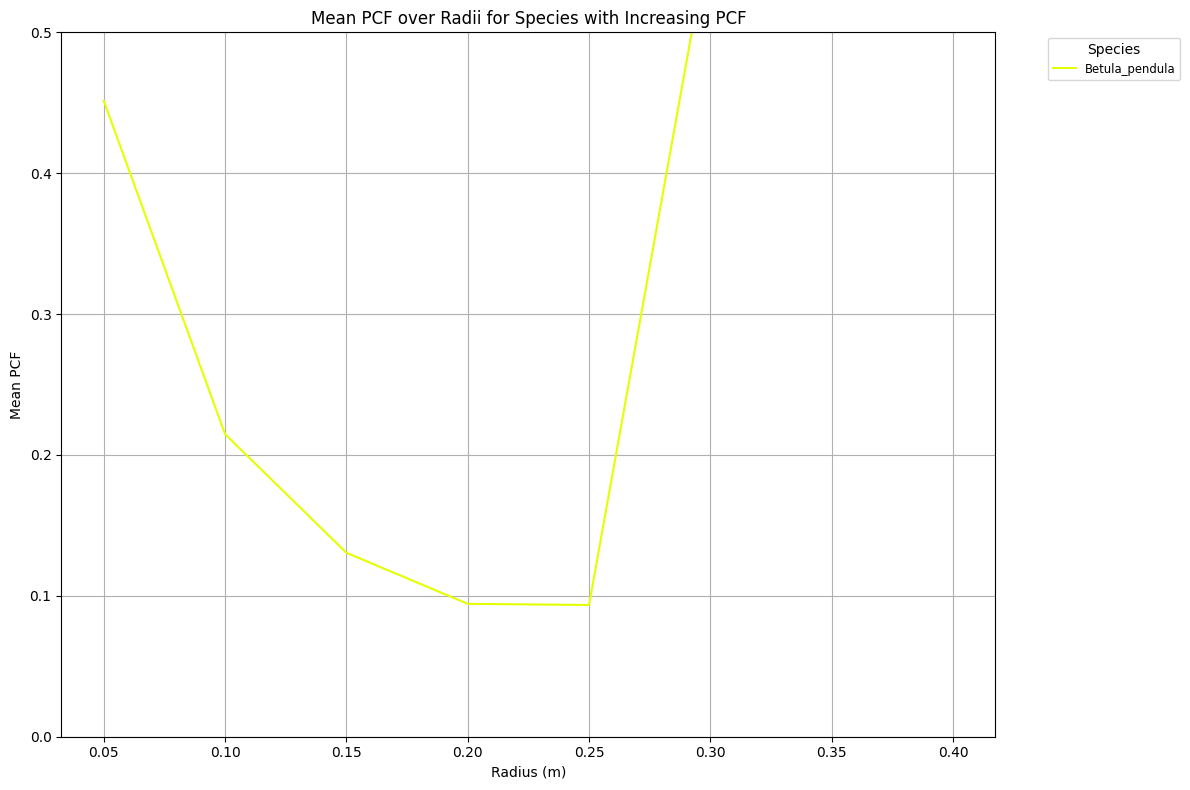

In [8]:
# Plot mean PCF for species where the curve goes up (increasing trend)
from scipy.stats import linregress

# Calculate slope for each species' mean PCF curve
increasing_species = []
for sp in all_species:
    y = mean_pcf_per_species_all[mean_pcf_per_species_all['species'] == sp][pcf_cols].values.flatten()
    slope, _, _, _, _ = linregress(radii[:8], y)
    if slope > 0:
        increasing_species.append(sp)

plt.figure(figsize=(12, 8))
for sp in increasing_species:
    plt.plot(
        radii[:8],
        mean_pcf_per_species_all[mean_pcf_per_species_all['species'] == sp][pcf_cols].values.flatten(),
        label=sp,
        color=species_colors_all[sp]
    )
plt.xlabel('Radius (m)')
plt.ylabel('Mean PCF')
plt.title('Mean PCF over Radii for Species with Increasing PCF')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.ylim((0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()